In [1]:
0

0

In [2]:
from fastai.vision.all import *

In [3]:
dataset_path = "./data"

In [4]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items = get_image_files,
    splitter = GrandparentSplitter(train_name="training", valid_name="testing"),
    get_y = parent_label,
    item_tfms=[Resize(192, method="Squish")]
).dataloaders(dataset_path, bs=64, num_workers=4)

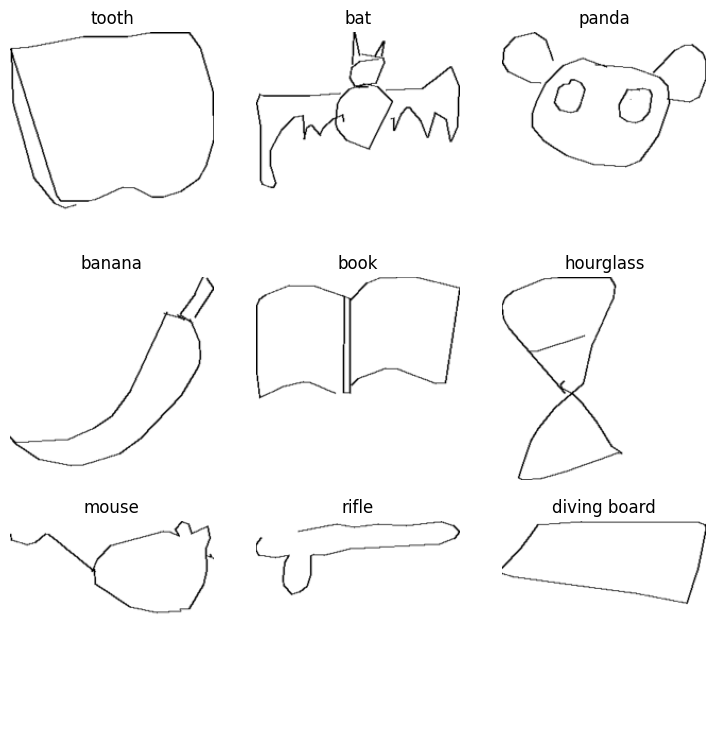

In [5]:
dls.show_batch()

In [18]:
learn = vision_learner(dls, 'convnext_small_in22k', metrics=error_rate)

c:\Users\shami\miniconda3\envs\gpu_env\lib\site-packages\timm\models\_factory.py:126: UserWarning: Mapping deprecated model name convnext_small_in22k to current convnext_small.fb_in22k.
  model = create_fn(


In [6]:
import torch

torch.cuda.is_available()

True

In [19]:
learn.to_fp16()

In [21]:
learn.fine_tune(5)

epoch,train_loss,valid_loss,error_rate,time
0,1.774420,1.557464,0.403726,02:34


epoch,train_loss,valid_loss,error_rate,time
0,1.264205,1.319771,0.353824,03:21
1,1.172673,1.288833,0.337941,03:27
2,0.920244,1.224265,0.324412,03:27
3,0.675578,1.182232,0.310490,03:28
4,0.538899,1.174974,0.309118,03:22


In [23]:
learn.predict(r"data\testing\wheel\_78.png")

('wheel',
 tensor(332),
 tensor([4.4966e-08, 4.2295e-11, 6.0879e-08, 3.2502e-09, 1.3564e-08, 1.6935e-06,
         1.7686e-08, 7.0862e-08, 5.4218e-09, 4.6647e-09, 1.6242e-08, 6.0840e-09,
         1.5293e-09, 9.4877e-09, 1.8786e-08, 7.5591e-07, 7.9273e-09, 3.1607e-08,
         3.8765e-06, 2.9147e-06, 2.5959e-08, 3.8533e-07, 8.5849e-05, 2.2824e-08,
         6.0149e-07, 1.0910e-08, 4.4729e-09, 5.7433e-09, 2.3417e-07, 5.9759e-08,
         1.5124e-08, 3.2516e-06, 9.6748e-09, 4.6007e-10, 9.3238e-08, 3.4806e-08,
         5.8526e-07, 1.2376e-07, 2.2536e-08, 5.8071e-07, 6.9627e-08, 1.8431e-08,
         2.3054e-07, 3.5906e-09, 2.9821e-10, 1.7205e-08, 4.4817e-09, 2.2818e-08,
         4.7653e-10, 2.4339e-10, 6.3551e-08, 1.0352e-06, 2.8348e-09, 4.7714e-08,
         5.4218e-09, 4.9061e-08, 7.6448e-10, 6.8806e-09, 6.0484e-09, 5.5431e-08,
         4.6974e-08, 1.6719e-07, 4.4036e-09, 1.2728e-09, 6.6601e-08, 3.1993e-10,
         3.2643e-06, 2.3148e-06, 3.2882e-08, 6.4963e-08, 6.0023e-08, 1.6236e-07,
    

In [24]:
learn.export('model.pkl')